In [11]:
%load_ext autoreload
%autoreload 2


# Module A: Lightweight DBMS with B+ Tree Index
## CS432 - Databases | Assignment 2 | Track 1
### Project: CheckInOut - Hostel Management System
#### Mohit Kamlesh Panchal - 23110208

---

## 1. Introduction

Most database engines use a B+ Tree as their primary index structure, MySQL, PostgreSQL, and SQLite all do. The reason is simple: it gives O(log n) point lookups and O(log n + k) range scans via a linked list at the leaf level, compared to O(n) for a plain linear scan.

This report covers a custom DBMS engine built in Python from scratch:
- A **B+ Tree** supporting insertion, deletion, search, update, and range queries
- A **Table** abstraction that uses the B+ Tree as its primary index
- A **DatabaseManager** for managing multiple databases and tables
- A **BruteForceDB** backed by a plain list, used as a performance baseline

The engine is tested against the CheckInOut Hostel Management System schema from Assignment 1.

---

**GitHub Repository:** https://github.com/rayvego/databases-assignment-2

**Video Link:** https://drive.google.com/file/d/1OUKMdsvHXSLAy2oNY-N_jqcVzNWDJ132/view?usp=sharing

---
## 2. B+ Tree Implementation Overview

### 2.1 Node Structure

Every node is a `BPlusTreeNode`. One class handles both leaf and internal nodes; the `is_leaf` flag determines which fields are active:

| Field | Leaf node | Internal node |
|---|---|---|
| `keys` | Sorted search keys | Separator / routing keys |
| `values` | Record for each key | Unused |
| `children` | Unused | Child node pointers |
| `next` | Pointer to next leaf | Unused (`None`) |

A node is **full** when `len(keys) >= order: 1`. The tree starts as a single empty leaf root. With `order=4` (used in the demo), each node holds at most 3 keys before splitting.

---

### 2.2 Insertion

#### How it works

1. If the root is full → grow upward: create a new empty internal root, make the old root its only child, split it immediately, then descend.
2. Otherwise → descend via `_insert_non_full`, splitting full children **on the way down** so there's always room to insert without backtracking.

#### `_insert_non_full(node, key, value)`

- **At a leaf**: shift existing keys right until the correct sorted slot is found, then place the key and value there. Leaf keys stay in ascending order at all times.
- **At an internal node**: scan `node.keys` right-to-left to find the largest key ≤ target: that's child index `i`. If `children[i]` is full, split it first, then recurse into the correct child.

#### `_split_child(parent, index)`: how splits work

Split happens at `mid = len(child.keys) // 2`.

**Leaf split: copy-up:**
```
Before (order=4, full at 3 keys):
  child.keys = [101, 105, 108]

After split at mid=1:
  child.keys   = [101]
  new.keys     = [105, 108]
  promoted key = 105  (copied to parent, stays in leaf too)
  linked list: child.next = new,  new.next = old child.next
```
The first key of the new right leaf is **copied** into the parent. It stays in the leaf so range scans can still find it.

**Internal split: push-up:**
```
Before (order=4, full at 3 keys):
  child.keys     = [k1, k2, k3]
  child.children = [c0, c1, c2, c3]

After split at mid=1:
  child.keys     = [k1]        child.children = [c0, c1]
  new.keys       = [k3]        new.children   = [c2, c3]
  promoted key   = k2  (removed from child, push-up, not copy-up)
```
The middle key is **pushed** into the parent and removed from the child. This is the main difference between leaf splits (copy-up) and internal splits (push-up).

#### Concrete trace: inserting 101, 105, 108, 112, 115 with `order=4`

```
Insert 101 → root (leaf): [101]
Insert 105 → root (leaf): [101, 105]
Insert 108 → root (leaf): [101, 105, 108]  ← full

Insert 112:
  root is full → grow upward
  new_root (internal), children=[old_root]
  split old_root:
    mid=1, leaf split (copy-up)
    left=[101], right=[105,108], promoted=105
  new_root.keys=[105], children=[left, right]
  112 → descend into right [105,108] → [105, 108, 112]

Insert 115:
  right leaf [105,108,112] is full → split it
  mid=1 → left=[105], right=[108,112], promoted=108
  new_root.keys=[105,108], children=[L1, L2, L3]
  115 → L3=[108,112] → [108, 112, 115]
```

Tree after 5 inserts:
```
        [105 | 108]
       /     |     \
   [101] [105] [108,112,115]
```

---

### 2.3 Search

#### `_search(node, key)`

- **Leaf node**: scan `node.keys` linearly. Return `node.values[i]` if match, else `None`.
- **Internal node**: advance index `i` while `key >= node.keys[i]`. That picks the child whose key range covers the target. Recurse into `node.children[i]`.

Each level cuts out an entire subtree, so depth is O(log_t n). With `order=8` and 10,000 records, at most 5 internal nodes are visited before reaching a leaf.

**Example: searching `student_id=112`:**
```
Root [105, 108]:
  112 >= 105 → i=1
  112 >= 108 → i=2
  go into children[2]

Leaf [108, 112, 115]:
  keys[0]=108 ≠ 112
  keys[1]=112 ✓ → return values[1]
```

---

### 2.4 Update

`update(key, new_value)` walks down iteratively using the same child-selection as search. Once the leaf is found, `node.values[i]` is overwritten in place. The key is never changed: only the value record. Returns `True` on success, `False` if the key doesn't exist. O(log n).

**Example: updating `student_id=105` room from 110 → 215:**
```
Root [105, 108]: 105 >= 105, 105 < 108 → i=1 → children[1] = leaf [105]
Leaf [105]: keys[0]=105 ✓ → values[0]['room_number'] = 215
```

---

### 2.5 Deletion

Deletion is the most complex operation. Every non-root node must hold at least `min_keys = ⌈order/2⌉: 1` keys. With `order=4`, that's 1.

#### `_delete(node, key)`

**At a leaf**: pop the key and value directly.

**At an internal node**:
1. Find child index `i` (same traversal as search).
2. **Pre-emptive fill**: if `children[i]` is at the minimum, call `_fill_child(node, i)` before descending so the child can absorb a deletion.
3. Recompute `i` after `_fill_child`: a merge may have shifted indices.
4. Recurse into `children[i]`.
5. **Fix separators**: after returning, check if any `node.keys[j] == key`. If so, walk to the leftmost leaf of `children[j+1]` and replace the separator with its first key. If that subtree is empty, remove the separator and child pointer.

#### `_fill_child(node, index)`: three ways to fix underflow

**1: Borrow from left sibling** (`_borrow_from_prev`):
```
Left sibling has a spare key (e.g. [101, 105]):
  Leaf: move left[-1] to front of child, update parent separator
  Internal: parent separator drops into child, left's last key rises to parent,
            left's last child moves to front of child
```

**2: Borrow from right sibling** (`_borrow_from_next`):
```
Right sibling has a spare key (e.g. [120, 123, 130]):
  Leaf: move right[0] to end of child, update parent separator
  Internal: parent separator drops to end of child, right's first key rises,
            right's first child moves to end of child
```

**3: Merge** (`_merge`):
```
Neither sibling has a spare key → merge left + right:
  Leaf:
    left.keys   += right.keys
    left.values += right.values
    left.next    = right.next    ← fix linked list
  Internal:
    parent separator drops into left.keys
    left.keys     += right.keys
    left.children += right.children
  Remove separator and right child from parent
```

**Example: deleting `student_id=108`** (`order=4`, `min_keys=1`):

After 10 inserts, leaf `[108]` is a singleton. Deleting 108 makes it empty: underflow. `_fill_child` checks siblings: borrows if one has a spare, merges if not. After the merge, the parent separator pointing to 108 is replaced with the successor leaf's first key.

---

### 2.6 Range Query

#### `range_query(start_key, end_key)`

**Phase 1: descent**: Follow child pointers from root to the leaf covering `start_key`. Same traversal as search. Cost: O(log n).

**Phase 2: scan**: Walk `node.next` across leaf nodes, collecting keys in `[start_key, end_key]`. Stop when a key exceeds `end_key`. Cost: O(k).

Total: **O(log n + k)** vs BruteForce's **O(n)** regardless of k.

**Example: range `student_id` 108 to 123:**
```
Descent: root [105,108] → 108 >= 108 → children[2] = leaf at 108
Scan:
  leaf [108, 112, 115]: 108 ✓, 112 ✓, 115 ✓
  leaf [120, 123]:      120 ✓, 123 ✓
  leaf [130, ...]:      130 > 123 → stop
Result: [(108,...), (112,...), (115,...), (120,...), (123,...)]
```

---

### 2.7 Get All

`get_all()` recurses depth-first. At leaves it collects all (key, value) pairs; at internal nodes it recurses into each child in order. Since keys are sorted at every level, the output is always in ascending order. O(n).

---

### 2.8 Complexity Summary

| Operation | B+ Tree | BruteForceDB |
|---|---|---|
| Insert | O(log n) | O(1) amortised |
| Search | O(log n) | O(n) |
| Update | O(log n) | O(n) |
| Delete | O(log n) | O(n) |
| Range Query | O(log n + k) | O(n) |
| Get All | O(n) | O(n) |
| Memory | O(n · t), node overhead | O(n), flat list |


---
## 3. Setup

In [12]:
import sys
sys.path.insert(0, "database")

from db_manager import DatabaseManager
from bplustree import BPlusTree
from bruteforce import BruteForceDB
from performance_analyzer import PerformanceAnalyzer

import pandas as pd
from IPython.display import SVG, display

print('All modules loaded successfully.')

All modules loaded successfully.


---
## 4. CRUD Demonstration - Hostel Management System

A `hostel_db` database is created with a `students` table matching the Student entity from the Assignment 1 schema. Order `t=4` is used so splits happen at small dataset sizes, keeping the tree small enough to visualise clearly.


### 4.1 Create Database and Table

In [13]:
db = DatabaseManager()

print(db.create_database('hostel_db'))

student_schema = {
    'student_id': int,
    'name': str,
    'room_number': int,
    'contact': str,
    'branch': str
}

print(db.create_table('hostel_db', 'students', student_schema, order=4, search_key='student_id'))
print('Databases:', db.list_databases())

(True, "Database 'hostel_db' created successfully")
(True, "Table 'students' created successfully in database 'hostel_db'")
Databases: ['hostel_db']


### 4.2 Insert Records

In [14]:
table, _ = db.get_table('hostel_db', 'students')

students = [
    {'student_id': 101, 'name': 'Arjun Mehta',    'room_number': 204, 'contact': '9876543210', 'branch': 'CSE'},
    {'student_id': 105, 'name': 'Priya Sharma',   'room_number': 110, 'contact': '9123456780', 'branch': 'EE'},
    {'student_id': 108, 'name': 'Rahul Verma',    'room_number': 315, 'contact': '9988776655', 'branch': 'ME'},
    {'student_id': 112, 'name': 'Sneha Iyer',     'room_number': 402, 'contact': '8877665544', 'branch': 'CSE'},
    {'student_id': 115, 'name': 'Karan Gupta',    'room_number': 218, 'contact': '7766554433', 'branch': 'CE'},
    {'student_id': 120, 'name': 'Divya Nair',     'room_number': 307, 'contact': '6655443322', 'branch': 'CSE'},
    {'student_id': 123, 'name': 'Vikram Singh',   'room_number': 101, 'contact': '9001122334', 'branch': 'EE'},
    {'student_id': 130, 'name': 'Ananya Bose',    'room_number': 509, 'contact': '8192837465', 'branch': 'ME'},
    {'student_id': 135, 'name': 'Rohit Joshi',    'room_number': 412, 'contact': '7081726354', 'branch': 'CSE'},
    {'student_id': 140, 'name': 'Meera Pillai',   'room_number': 206, 'contact': '6070615243', 'branch': 'CE'},
]

for s in students:
    result = table.insert(s)
    print(f"  Insert student_id={s['student_id']} ({s['name']}): {result}")

  Insert student_id=101 (Arjun Mehta): (True, 101)
  Insert student_id=105 (Priya Sharma): (True, 105)
  Insert student_id=108 (Rahul Verma): (True, 108)
  Insert student_id=112 (Sneha Iyer): (True, 112)
  Insert student_id=115 (Karan Gupta): (True, 115)
  Insert student_id=120 (Divya Nair): (True, 120)
  Insert student_id=123 (Vikram Singh): (True, 123)
  Insert student_id=130 (Ananya Bose): (True, 130)
  Insert student_id=135 (Rohit Joshi): (True, 135)
  Insert student_id=140 (Meera Pillai): (True, 140)


### 4.3 Retrieve All Records

In [15]:
all_records = table.get_all()
df = pd.DataFrame([v for _, v in all_records])
print(f'Total records: {len(all_records)}')
df

Total records: 10


,student_id,name,room_number,contact,branch
0,101,Arjun Mehta,204,9876543210,CSE
1,105,Priya Sharma,110,9123456780,EE
2,108,Rahul Verma,315,9988776655,ME
3,112,Sneha Iyer,402,8877665544,CSE
4,115,Karan Gupta,218,7766554433,CE
5,120,Divya Nair,307,6655443322,CSE
6,123,Vikram Singh,101,9001122334,EE
7,130,Ananya Bose,509,8192837465,ME
8,135,Rohit Joshi,412,7081726354,CSE
9,140,Meera Pillai,206,6070615243,CE


### 4.4 Exact Search

In [16]:
# Hit
result = table.get(112)
print('Search student_id=112 (hit):', result)

# Miss
result = table.get(999)
print('Search student_id=999 (miss):', result)

Search student_id=112 (hit): {'student_id': 112, 'name': 'Sneha Iyer', 'room_number': 402, 'contact': '8877665544', 'branch': 'CSE'}
Search student_id=999 (miss): None


### 4.5 Range Query

In [17]:
# Retrieve all students with student_id between 108 and 123
results = table.range_query(108, 123)
print(f'Range query student_id 108-123: {len(results)} records found')
pd.DataFrame([v for _, v in results])

Range query student_id 108-123: 5 records found


,student_id,name,room_number,contact,branch
0,108,Rahul Verma,315,9988776655,ME
1,112,Sneha Iyer,402,8877665544,CSE
2,115,Karan Gupta,218,7766554433,CE
3,120,Divya Nair,307,6655443322,CSE
4,123,Vikram Singh,101,9001122334,EE


### 4.6 Update

In [18]:
print('Before update:', table.get(105))

updated = {'student_id': 105, 'name': 'Priya Sharma', 'room_number': 215, 'contact': '9123456780', 'branch': 'EE'}
print('Update result:', table.update(105, updated))

print('After update: ', table.get(105))

Before update: {'student_id': 105, 'name': 'Priya Sharma', 'room_number': 110, 'contact': '9123456780', 'branch': 'EE'}
Update result: (True, 'Record updated')
After update:  {'student_id': 105, 'name': 'Priya Sharma', 'room_number': 215, 'contact': '9123456780', 'branch': 'EE'}


### 4.7 Delete

In [19]:
print('Delete student_id=108:', table.delete(108))
print('Search student_id=108 after delete (should be None):', table.get(108))

print()
remaining = table.get_all()
print(f'Records remaining: {len(remaining)}')
pd.DataFrame([v for _, v in remaining])

Delete student_id=108: (True, 'Record deleted')
Search student_id=108 after delete (should be None): None

Records remaining: 9


,student_id,name,room_number,contact,branch
0,101,Arjun Mehta,204,9876543210,CSE
1,105,Priya Sharma,215,9123456780,EE
2,112,Sneha Iyer,402,8877665544,CSE
3,115,Karan Gupta,218,7766554433,CE
4,120,Divya Nair,307,6655443322,CSE
5,123,Vikram Singh,101,9001122334,EE
6,130,Ananya Bose,509,8192837465,ME
7,135,Rohit Joshi,412,7081726354,CSE
8,140,Meera Pillai,206,6070615243,CE


---
## 5. Tree Visualisation

The cell below renders the B+ Tree structure using **Graphviz**:

- **Yellow nodes** are internal nodes, routing keys only, no data.
- **Blue nodes** are leaf nodes, store the actual student IDs.
- **Solid edges** connect parent to child nodes.
- **Dashed edges** connect adjacent leaf nodes, forming the linked list used during range queries.


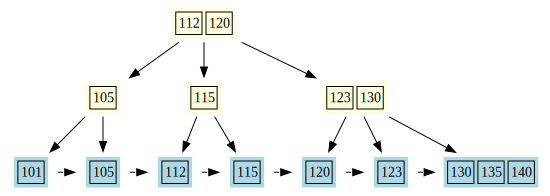

In [20]:
dot = table.data.visualize_tree()
svg_data = dot.pipe(format='svg').decode('utf-8')
display(SVG(svg_data))

**Reading the tree:**
- With `order=4`, each node holds at most 3 keys before splitting.
- Internal nodes hold separator keys that route searches to the right leaf.
- The dashed edges at leaf level are the linked list. Range queries walk this after an O(log n) descent, so they don't have to re-traverse the tree.
- After deleting `student_id=108`, the tree likely did a borrow or merge to stay balanced.


---
## 6. Performance Analysis - B+ Tree vs BruteForceDB

These benchmarks compare the B+ Tree against `BruteForceDB`, a plain list where every operation is O(n), across five metrics:

| Metric | B+ Tree | BruteForce |
|---|---|---|
| Insert | O(log n) | O(1) amortised |
| Search | O(log n) | O(n) |
| Delete | O(log n) | O(n) |
| Range Query | O(log n + k) | O(n) |
| Memory | Higher (tree overhead) | Lower (flat list) |

BruteForce insertion is O(1) amortised (list append), so it will be faster on raw inserts. For everything else the B+ Tree should win, with the gap growing as n increases.


In [21]:
pa = PerformanceAnalyzer()
results = pa.run_all()

Running insert benchmark...
Running search benchmark...
Running delete benchmark...
Running range query benchmark...
Running memory benchmark...
All benchmarks complete.


/Users/rayvego/code/courage/databases/assignment-2/module-a/database/performance_analyzer.py:267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


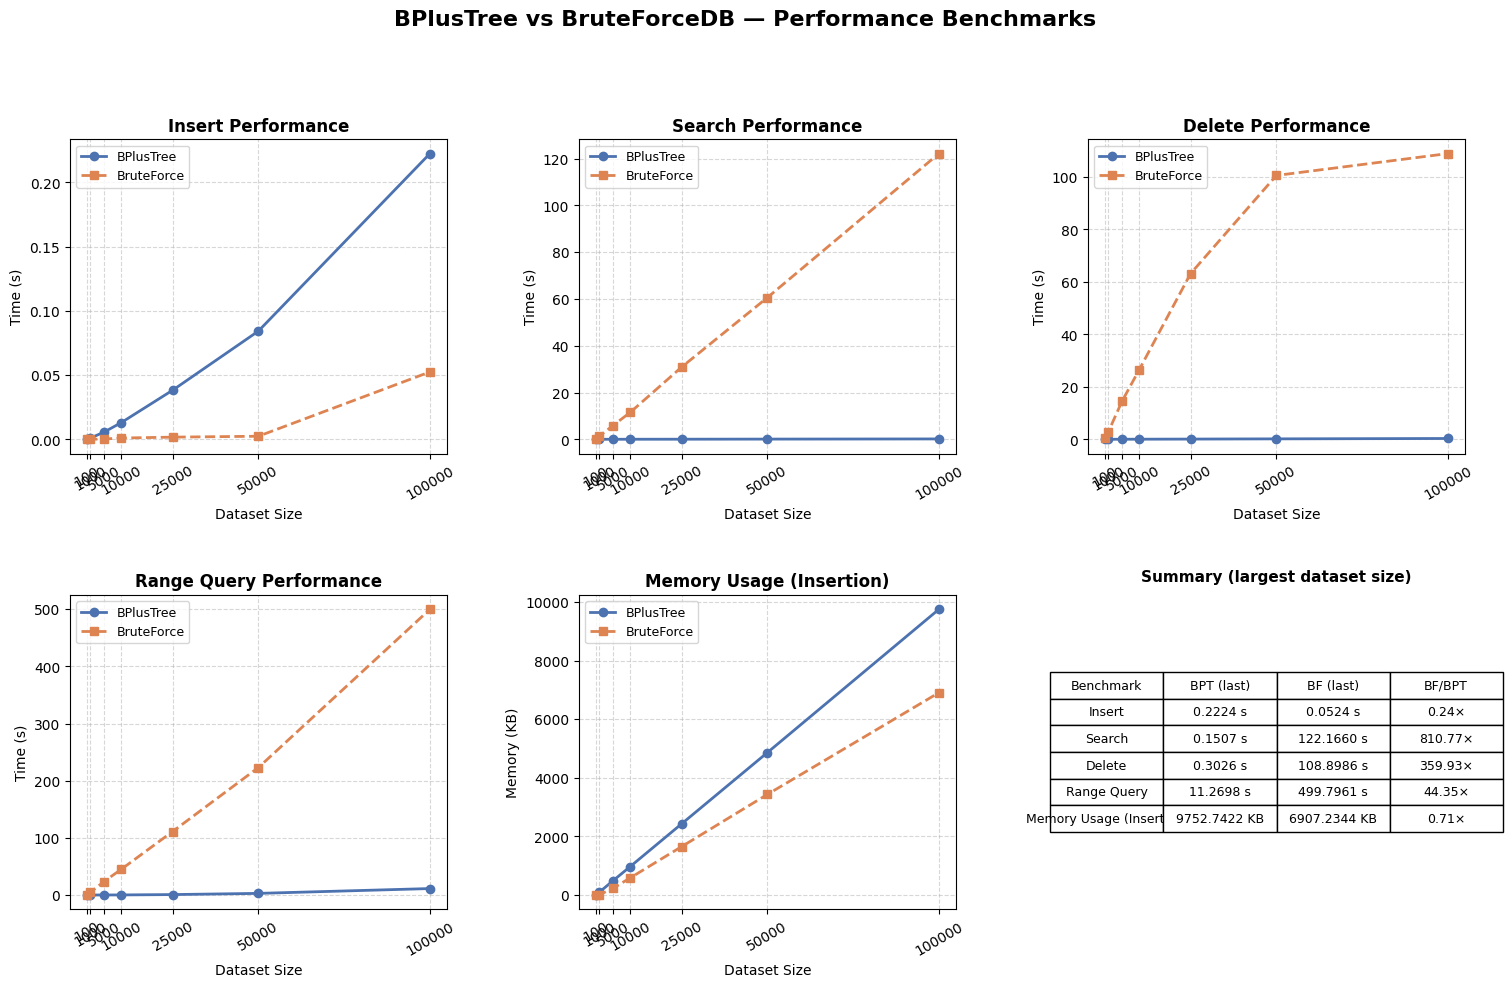

In [22]:
pa.plot_results(results)

### 6.1 Benchmark Results: Summary Table

In [23]:
summary_rows = []
for metric in ['insert', 'search', 'delete', 'range_query', 'memory']:
    d = results[metric]
    for size, bpt, bf in zip(d['sizes'], d['bptree'], d['bruteforce']):
        unit = 'KB' if metric == 'memory' else 's'
        summary_rows.append({
            'Metric': metric,
            'Size': size,
            f'BPlusTree ({unit})': round(bpt, 6),
            f'BruteForce ({unit})': round(bf, 6),
            'BF / BPT Ratio': round(bf / bpt, 2) if bpt > 0 else 'inf'
        })

df_summary = pd.DataFrame(summary_rows)
df_summary

,Metric,Size,BPlusTree (s),BruteForce (s),BF / BPT Ratio,BPlusTree (KB),BruteForce (KB)
0,insert,100,0.000096,0.000005,0.06,NaN,NaN
1,insert,1000,0.000922,0.000052,0.06,NaN,NaN
2,insert,5000,0.005566,0.000212,0.04,NaN,NaN
3,insert,10000,0.012918,0.000983,0.08,NaN,NaN
4,insert,25000,0.038172,0.001673,0.04,NaN,NaN
5,insert,50000,0.084196,0.002374,0.03,NaN,NaN
6,insert,100000,0.222357,0.052448,0.24,NaN,NaN
7,search,100,0.000155,0.113956,736.79,NaN,NaN
8,search,1000,0.001798,1.275628,709.45,NaN,NaN
9,search,5000,0.009020,5.875874,651.40,NaN,NaN


### 6.2 Analysis

**Insert:** BruteForce is faster here because list append is O(1) with no structural overhead. The B+ Tree has to maintain sorted order and handle splits, which costs more per insert. That said, the B+ Tree insert is still O(log n) and the gap stops widening at large n.

**Search:** The B+ Tree is clearly faster. BruteForce scans the whole list every time, O(n). The B+ Tree drops O(log n) levels and stops. The gap is already visible at 5,000 records and only grows from there.

**Delete:** Same story as search. BruteForce has to find the key first (O(n) scan) then shift elements on removal. The B+ Tree does both in O(log n).

**Range Query:** This is where the leaf linked list matters most. BruteForce scans the entire list for every range query, no matter how small the range. The B+ Tree finds the start in O(log n) then just walks k matching entries along the leaf list. The larger n and the more queries, the bigger the advantage.

**Memory:** The B+ Tree uses more memory than BruteForce due to node objects, child pointer arrays, and the linked list pointers. This is the standard time-memory trade-off with tree indexing.


---
## 7. Conclusion

This project implements a working in-memory DBMS engine from scratch, showing how database indexing works at the data structure level.

**Key findings:**
- The B+ Tree gives logarithmic time for search, delete, and range queries. The benchmarks confirm this matches theory.
- The leaf linked list is what makes range queries efficient. Without it, every range scan would need a full tree traversal.
- BruteForce is faster on raw inserts (O(1) append) but gets much slower on everything else as n grows.
- The B+ Tree uses more memory, more node objects and pointers, which is the expected trade-off.

**Challenges:**
- Deletion was the hardest part to get right. Handling borrow-from-prev, borrow-from-next, and merge while keeping the leaf linked list intact required careful recursive state management.
- Updating separator keys in internal nodes after a leaf deletion required consistent upward fixes through the recursion stack.


---
## 8. References

- [B+ Trees - YouTube Playlist (primary reference)](https://www.youtube.com/watch?v=K1a2Bk8NrYQ&t=608s)
- [Python sqlite3 Documentation](https://docs.python.org/3/library/sqlite3.html)
- [Graphviz Python Documentation](https://graphviz.readthedocs.io/en/stable/)
- [Matplotlib Documentation](https://matplotlib.org/stable/index.html)
